# Logistics Regression

- Type of supervised learning that focuses on the classification Problems
- Logistic Regression is a supervised machine learning algorithm used for classification problems. Instead of predicting continuous value (like in LR), it predicts the probability that an input belongs to a particular class. The output is a value between 0 and 1
- Which can then be converted into a class label such as Yes/No, Spam/Not Spam or Approved or Rejected

## Formula

### Step 1: Compute Linear Score
$$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

Where: 
- ($x_i$) = input features
- ($w_i$) = learned weight
- ($b$) = bias

### Step 2: Apply the Sigmoid Function
$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

The sigmoid function converts any number iinto a probability between 0 and 1

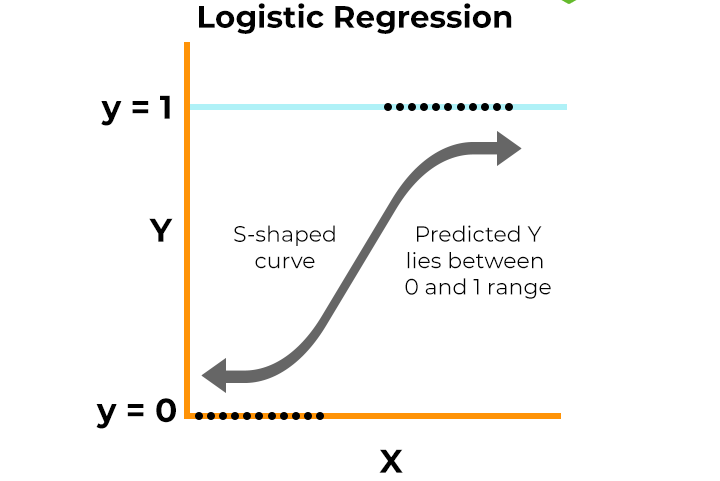



In [1]:
from sklearn import datasets
cancer = datasets.load_breast_cancer()

In [2]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [4]:
X = cancer.data
y = cancer.target

In [5]:
X.shape, y.shape

((569, 30), (569,))

In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# Train - test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape, X_test.shape

((455, 30), (114, 30))

In [9]:
569*0.2

113.80000000000001

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000, random_state=23)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,23
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test)

In [12]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix

acc = accuracy_score(y_test, y_pred) * 100

In [14]:
acc

95.6140350877193

In [15]:
print(f"Logistic Regression model Accuracy: {acc:.2f}%")

Logistic Regression model Accuracy: 95.61%


In [16]:
import numpy as np

y_true = np.where(y_test == 1, 'Cancer', 'No Cancer')
y_true

array(['Cancer', 'No Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'No Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'Cancer', 'No Cancer', 'Cancer', 'No Cancer', 'Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'No Cancer',
       'No Cancer', 'Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'Cancer', 'Cancer', 'No Cancer', 'Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer',
       'Cancer', 'No Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'No Cancer', 'Cancer', 'Cancer', 'No Cancer',
       'No Cancer', 'Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'No Cancer', '

In [17]:
y_pred = np.where(y_pred == 1, 'Cancer', 'No Cancer')
y_pred

array(['Cancer', 'No Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'No Cancer', 'No Cancer', 'Cancer', 'Cancer',
       'Cancer', 'No Cancer', 'Cancer', 'No Cancer', 'Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'No Cancer', 'Cancer',
       'Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'Cancer', 'No Cancer', 'Cancer', 'No Cancer',
       'Cancer', 'Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer', 'No Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'No Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'No Cancer',
       'No Cancer', 'Cancer', 'Cancer', 'No Cancer', 'No Cancer',
       'Cancer', 'No Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer',
       'Cancer', 'Cancer', 'No Cancer', 'Cancer', 

In [18]:
labels = ['No Cancer', 'Cancer']
cm  = confusion_matrix(y_true, y_pred, labels=labels)
cm

array([[39,  4],
       [ 1, 70]])

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

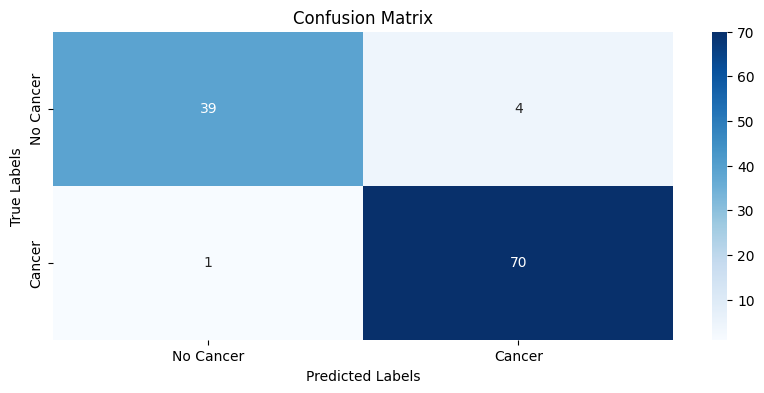

In [22]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    cm, 
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

<Axes: >

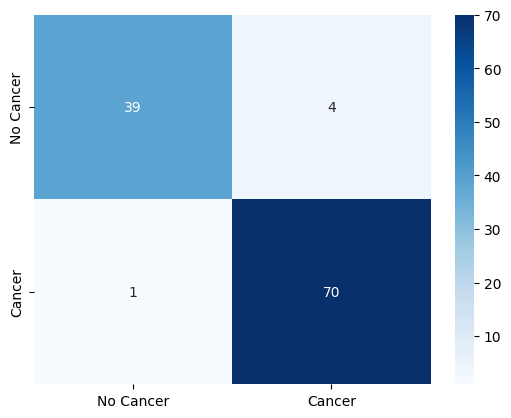

In [23]:
sns.heatmap(
    cm, 
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

In [27]:
y_pred_new = model.predict(X_train)
y_pred_new

array([1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,

In [29]:
y_pred.shape, y_pred_new.shape

((114,), (455,))